# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy import stats

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

# Data Analysis

In [2]:
df = pd.read_csv('../datasets/fish_data.csv')

In [3]:
df.head(10)

,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31
5,Anabas testudineus,9.35,3.28,0.35
6,Anabas testudineus,9.42,3.33,0.35
7,Anabas testudineus,7.92,3.13,0.39
8,Anabas testudineus,6.98,3.16,0.45
9,Anabas testudineus,8.42,3.26,0.39


In [4]:
df.shape

(4080, 4)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   species    4080 non-null   str    
 1   length     4080 non-null   float64
 2   weight     4080 non-null   float64
 3   w_l_ratio  4080 non-null   float64
dtypes: float64(3), str(1)
memory usage: 127.6 KB


In [6]:
df.describe()

,length,weight,w_l_ratio
count,4080.000000,4080.000000,4080.000000
mean,17.353544,3.739875,0.252782
std,7.114684,1.040365,0.123046
min,6.360000,2.050000,0.080000
25%,11.327500,3.070000,0.170000
50%,17.350000,3.310000,0.190000
75%,22.585000,4.100000,0.340000
max,33.860000,6.290000,0.640000


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(109)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(3971, 4)

In [11]:
Y = pd.DataFrame()

In [12]:
X = df.drop('species', axis=1)
Y["Species"] = df.species

In [13]:
X

,length,weight,w_l_ratio
0,10.66,3.45,0.32
1,6.91,3.27,0.47
2,8.38,3.46,0.41
3,7.57,3.36,0.44
4,10.83,3.38,0.31
...,...,...,...
4074,30.61,6.08,0.20
4075,30.56,6.12,0.20
4076,29.66,6.11,0.21
4077,32.81,6.25,0.19


In [14]:
Y.value_counts()

Species               
Setipinna taty            476
Anabas testudineus        462
Otolithoides biauritus    456
Pethia conchonius         454
Polynemus paradiseus      454
Sillaginopsis panijus     429
Otolithoides pama         428
Coilia dussumieri         409
Puntius lateristriga      403
Name: count, dtype: int64

In [15]:
z_scores = pd.DataFrame(stats.zscore(X))
z_scores

,0,1,2
0,-0.945026,-0.270714,0.553657
1,-1.475775,-0.445401,1.776943
2,-1.267721,-0.261009,1.287629
3,-1.382363,-0.358058,1.532286
4,-0.920966,-0.338648,0.472105
...,...,...,...
3966,1.878556,2.281659,-0.424972
3967,1.871479,2.320478,-0.424972
3968,1.744100,2.310774,-0.343420
3969,2.189929,2.446641,-0.506525


In [16]:
z_scores.describe().round(3)

,0,1,2
count,3971.000,3971.000,3971.000
mean,-0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-1.554,-1.629,-1.404
25%,-0.846,-0.639,-0.670
50%,0.003,-0.407,-0.507
75%,0.736,0.350,0.717
max,2.339,2.485,3.163


# Data Visualization

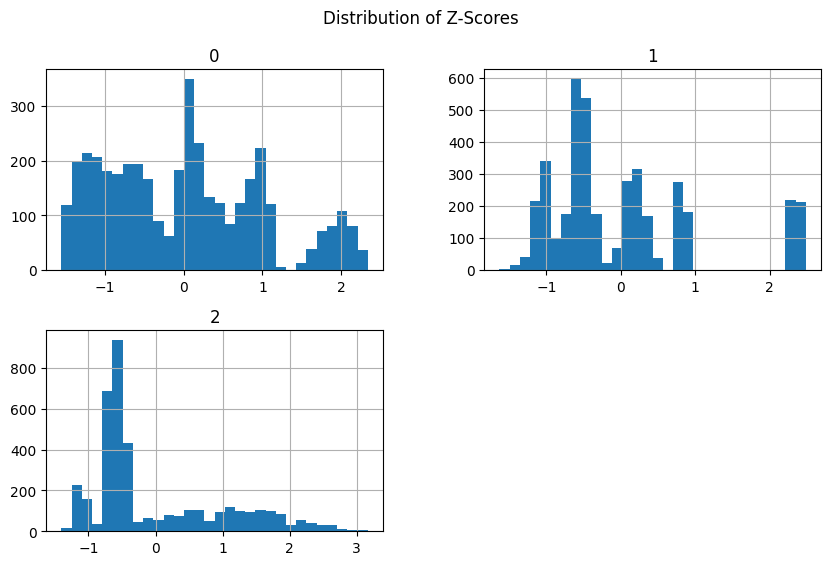

In [17]:
z_scores.hist(figsize=(10, 6), bins=30)
plt.suptitle("Distribution of Z-Scores")
plt.show()

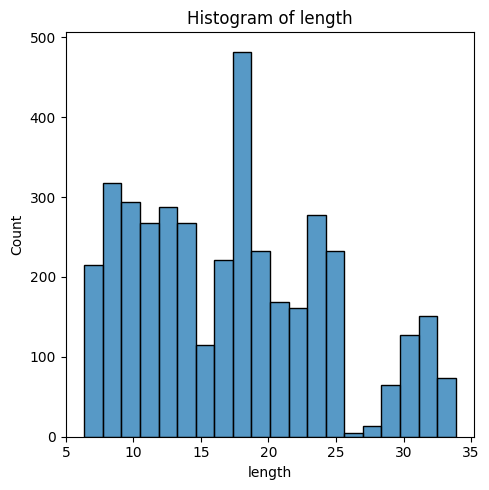

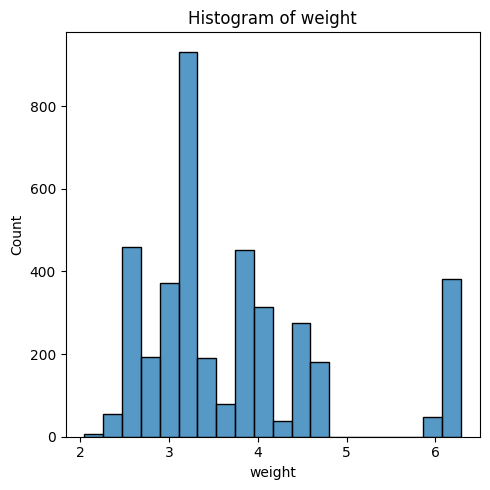

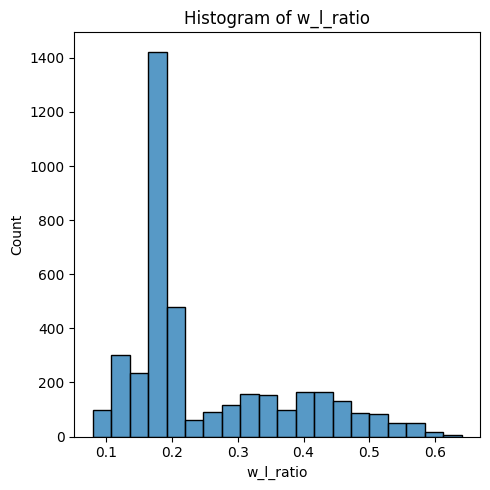

In [18]:
for column in X:
    plt.figure(figsize=(5, 5))
    sns.histplot(data=X, x=column, bins=20)
    plt.title(f'Histogram of {column}')
    
    plt.tight_layout()
    plt.show()

<Axes: xlabel='length', ylabel='weight'>

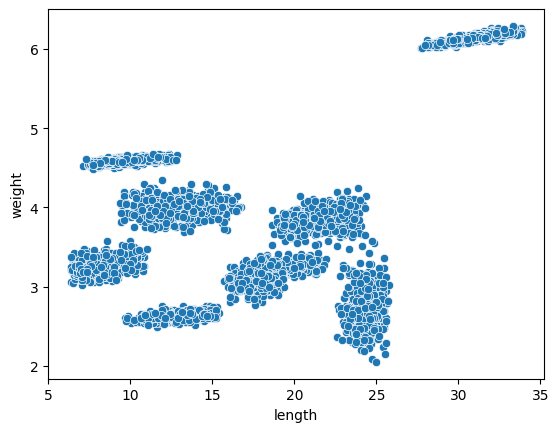

In [19]:
sns.scatterplot(
    x=df.length,
    y=df.weight
)

<Axes: xlabel='length', ylabel='w_l_ratio'>

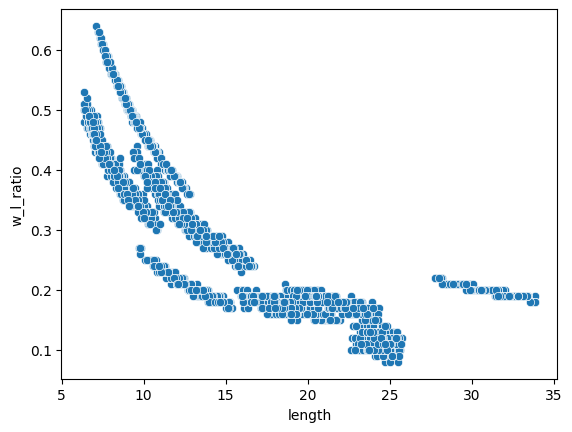

In [20]:
sns.scatterplot(
    x=df.length,
    y=df.w_l_ratio
)

<Axes: xlabel='weight', ylabel='w_l_ratio'>

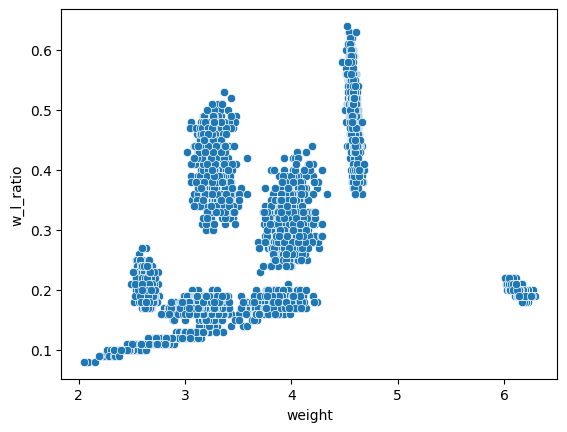

In [21]:
sns.scatterplot(
    x=df.weight,
    y=df.w_l_ratio
)

# Data Scaling

In [22]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
X_scaled

array([[0.15636364, 0.33018868, 0.42857143],
       [0.02      , 0.28773585, 0.69642857],
       [0.07345455, 0.33254717, 0.58928571],
       ...,
       [0.84727273, 0.95754717, 0.23214286],
       [0.96181818, 0.99056604, 0.19642857],
       [0.91854545, 0.96462264, 0.19642857]], shape=(3971, 3))

In [24]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(3971, 2)


In [25]:
X_pca.round(3)

array([[-0.277, -0.   ],
       [-0.54 ,  0.098],
       [-0.427,  0.082],
       ...,
       [ 0.561,  0.454],
       [ 0.681,  0.467],
       [ 0.639,  0.444]], shape=(3971, 2))

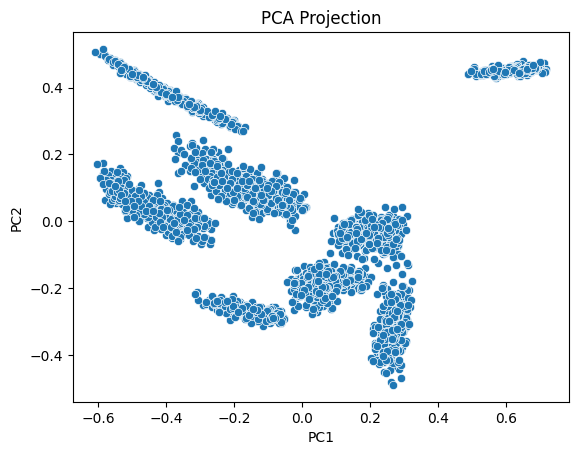

In [26]:
sns.scatterplot(x=X_pca[:,0], y= X_pca[:,1])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection')
plt.show()

In [27]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

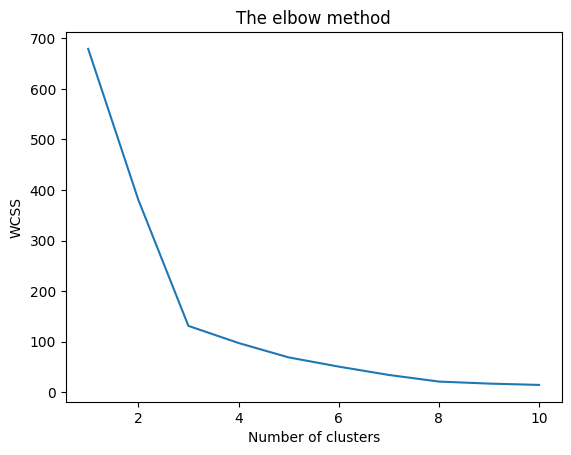

In [28]:
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [29]:
sil_scores = []

for k in range(2,20):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)

    sil_scores.append(silhouette_score(X_scaled, labels))

In [30]:
sil_scores

[0.584108775400153,
 0.6160690059516349,
 0.5499080810217866,
 0.4659436167177436,
 0.5245870265268592,
 0.5933596110072901,
 0.5822613703996521,
 0.5733755484529081,
 0.6460102957209536,
 0.6387211342050395,
 0.5674512223030935,
 0.5636180120001137,
 0.5248324760790896,
 0.5250882935143757,
 0.5133936403697354,
 0.49366541320596236,
 0.48405354721925453,
 0.47668093673528]

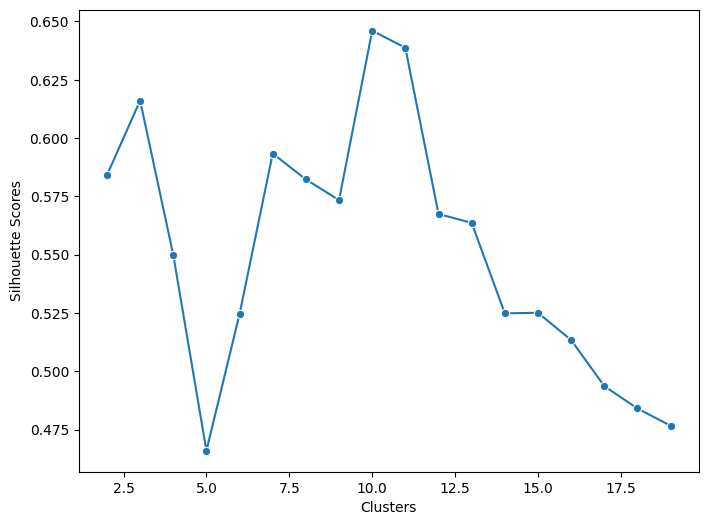

In [31]:
plt.figure(figsize=(8,6))

sns.lineplot(
    x=range(2,20),
    y=sil_scores,
    marker='o'
)

plt.xlabel('Clusters')
plt.ylabel('Silhouette Scores')
plt.show()

In [32]:
X_transformed = scaler.inverse_transform(X_scaled)

pd.DataFrame(X_transformed, columns=X.columns).head()

,length,weight,w_l_ratio
0,10.66,3.45,0.32
1,6.91,3.27,0.47
2,8.38,3.46,0.41
3,7.57,3.36,0.44
4,10.83,3.38,0.31


In [33]:
kmeans = KMeans(n_clusters=10, max_iter=100)
y_kmeans = kmeans.fit_predict(X_scaled)

In [34]:
np.unique(y_kmeans)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

In [35]:
d = pd.DataFrame()

In [36]:
d = X.copy()
d['y_kmeans'] = y_kmeans.copy()

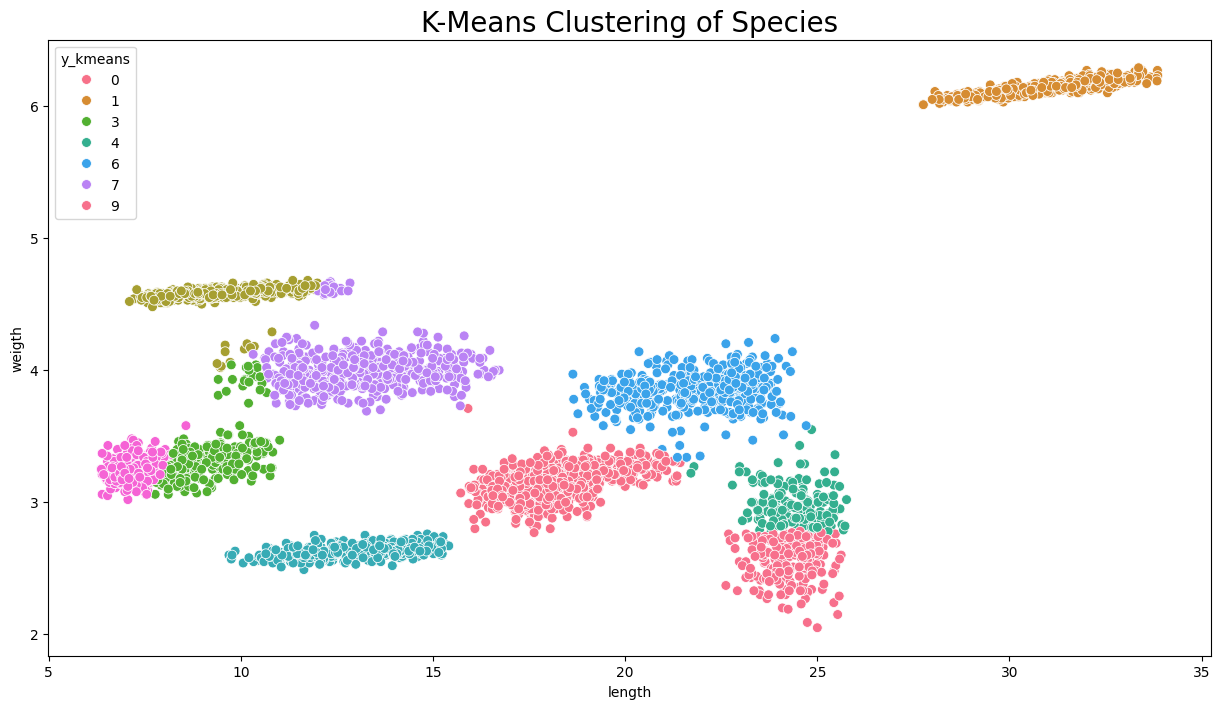

In [37]:
plt.figure(figsize= (15,8))

sns.scatterplot(
    x = 'length',
    y = 'weight',
    hue = 'y_kmeans',
    palette = 'husl',
    s=50,
    data=d
)

plt.title('K-Means Clustering of Species', fontsize=20)
plt.xlabel('length')
plt.ylabel('weigth')

plt.show()

In [38]:
silhouette_score(X_scaled, y_kmeans)

0.6193170696996696

# K-Distance Graph

In [39]:
neighbors = NearestNeighbors(n_neighbors=20)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

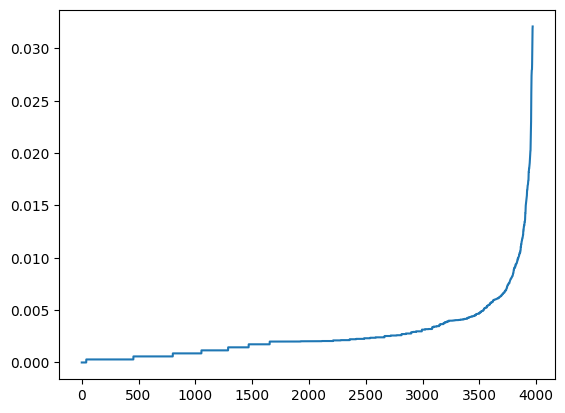

In [40]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

# DBSCAN

In [41]:
dbscan = DBSCAN(
    eps = 0.025,
    min_samples=10
)

y_dbscan = dbscan.fit_predict(X_pca)

In [42]:
np.unique(y_dbscan)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7])

In [43]:
y_dbscan

array([0, 0, 0, ..., 7, 7, 7], shape=(3971,))

In [44]:
d['y_dbscan'] = y_dbscan.copy()

In [45]:
d

,length,weight,w_l_ratio,y_kmeans,y_dbscan
0,10.66,3.45,0.32,3,0
1,6.91,3.27,0.47,8,0
2,8.38,3.46,0.41,3,0
3,7.57,3.36,0.44,8,0
4,10.83,3.38,0.31,3,0
...,...,...,...,...,...
4074,30.61,6.08,0.20,1,7
4075,30.56,6.12,0.20,1,7
4076,29.66,6.11,0.21,1,7
4077,32.81,6.25,0.19,1,7


In [46]:
outliers = d[d['y_dbscan']==-1]

In [47]:
outliers

,length,weight,w_l_ratio,y_kmeans,y_dbscan
11,10.27,3.16,0.31,3,-1
30,10.81,3.26,0.30,3,-1
155,10.76,3.20,0.30,3,-1
182,10.59,3.25,0.31,3,-1
252,10.78,3.26,0.30,3,-1
...,...,...,...,...,...
2727,9.85,2.63,0.27,5,-1
2794,9.69,2.60,0.27,5,-1
2911,9.77,2.60,0.27,5,-1
3160,16.06,3.25,0.20,0,-1


In [48]:
X.shape

(3971, 3)

In [49]:
X_dbscan = d[d['y_dbscan']>-1]

In [50]:
X_dbscan.shape

(3908, 5)

Text(0.5, 1.0, 'Outliers')

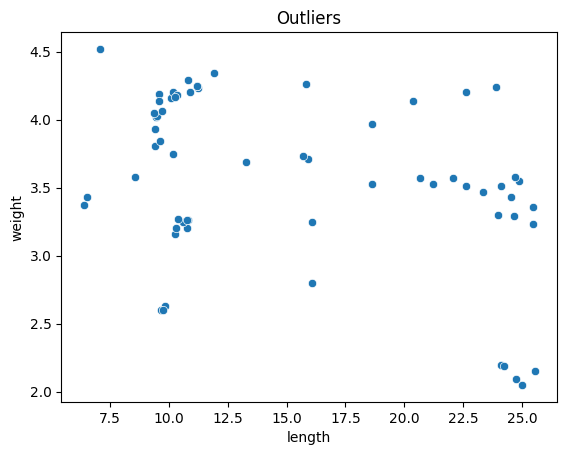

In [51]:
sns.scatterplot(
    x=outliers.length,
    y=outliers.weight,
)

plt.ylabel('weight')
plt.xlabel('length')
plt.title('Outliers')

In [52]:
species = np.unique(Y.Species)

In [53]:
len(species)

9

In [54]:
plot_df = X.copy()
plot_df['Species'] = Y.Species

In [55]:
plot_df.head()

,length,weight,w_l_ratio,Species
0,10.66,3.45,0.32,Anabas testudineus
1,6.91,3.27,0.47,Anabas testudineus
2,8.38,3.46,0.41,Anabas testudineus
3,7.57,3.36,0.44,Anabas testudineus
4,10.83,3.38,0.31,Anabas testudineus


In [56]:
plot_df.shape

(3971, 4)

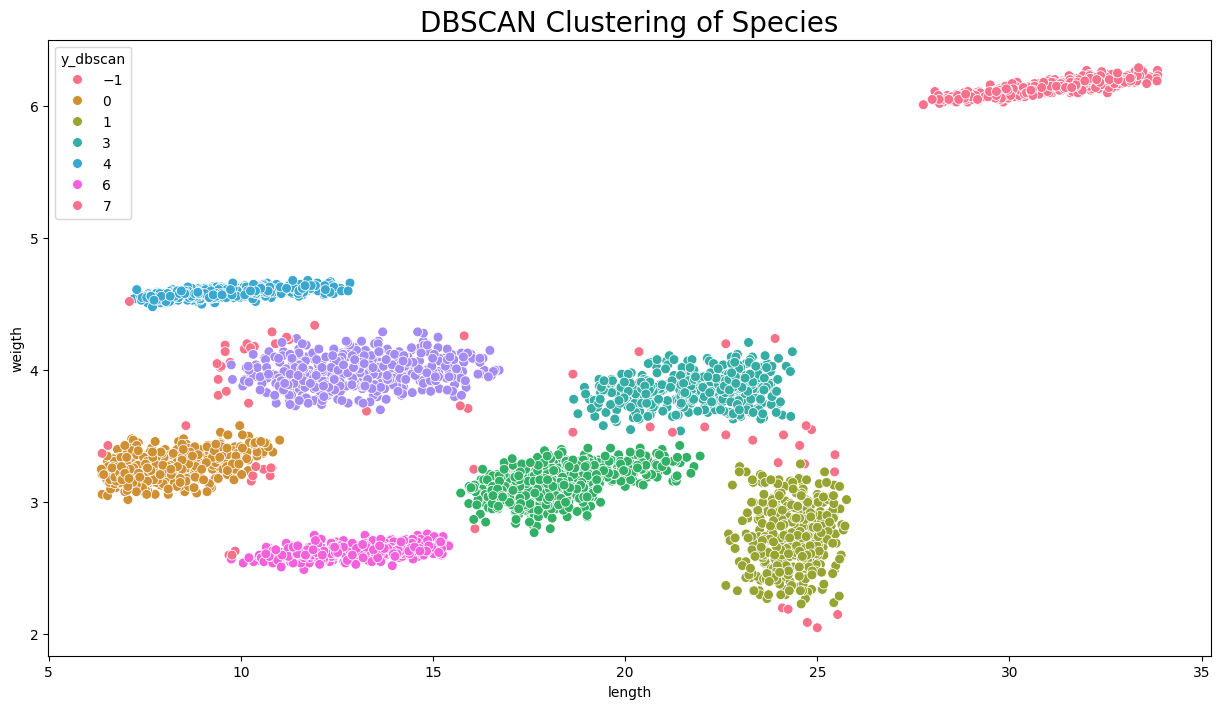

In [57]:
plt.figure(figsize= (15,8))

sns.scatterplot(
    x = 'length',
    y = 'weight',
    hue = 'y_dbscan',
    palette = 'husl',
    s=50,
    data=d
)

plt.title('DBSCAN Clustering of Species', fontsize=20)
plt.xlabel('length')
plt.ylabel('weigth')

plt.show()

In [58]:
silhouette_score(X_pca, y_dbscan)

0.6569618658527239

Text(0.5, 0, 'length')

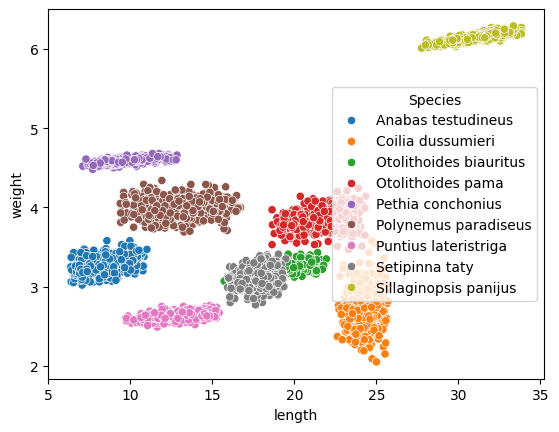

In [59]:
sns.scatterplot(
    x='length',
    y='weight',
    hue = 'Species',
    data=plot_df
)

plt.ylabel('weight')
plt.xlabel('length')

Text(0.5, 1.0, 'Cluster not formed')

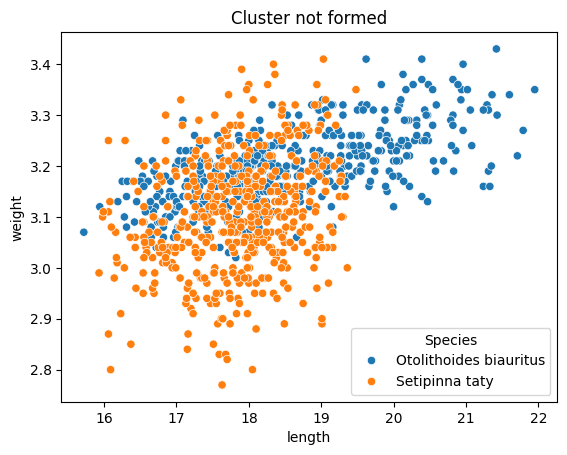

In [60]:
sns.scatterplot(
    x='length',
    y='weight',
    hue = 'Species',
    data=plot_df[(plot_df['Species']=='Setipinna taty') | (plot_df['Species']=='Otolithoides biauritus')]
)

plt.ylabel('weight')
plt.xlabel('length')
plt.title('Cluster not formed')

# Gaussian Mixture Model

### Calculate BIC - Bayesian Information Criterion

In [61]:
bic_scores = []

for k in range(1,20):
    gmm = GaussianMixture(
        n_components = k,
        random_state = 42
    )
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))

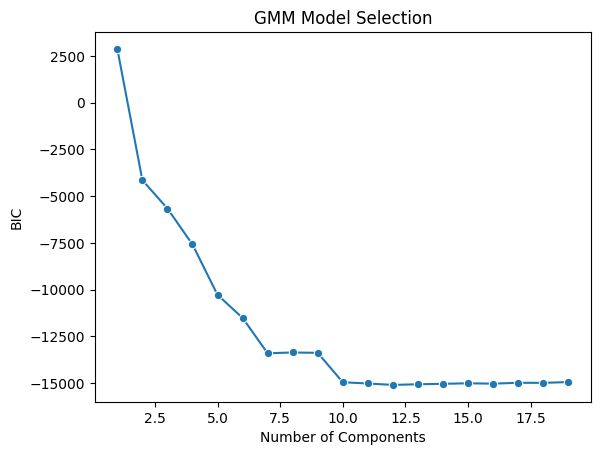

In [62]:
sns.lineplot(
    x=range(1,20),
    y=bic_scores,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("GMM Model Selection")
plt.show()

In [63]:
gmm = GaussianMixture(
    n_components=10,
    random_state=42
)

y_gmm = gmm.fit_predict(X_pca)

In [64]:
np.unique(y_gmm)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [65]:
d['y_gmm'] = y_gmm

In [66]:
d

,length,weight,w_l_ratio,y_kmeans,y_dbscan,y_gmm
0,10.66,3.45,0.32,3,0,1
1,6.91,3.27,0.47,8,0,8
2,8.38,3.46,0.41,3,0,1
3,7.57,3.36,0.44,8,0,8
4,10.83,3.38,0.31,3,0,1
...,...,...,...,...,...,...
4074,30.61,6.08,0.20,1,7,2
4075,30.56,6.12,0.20,1,7,2
4076,29.66,6.11,0.21,1,7,2
4077,32.81,6.25,0.19,1,7,2


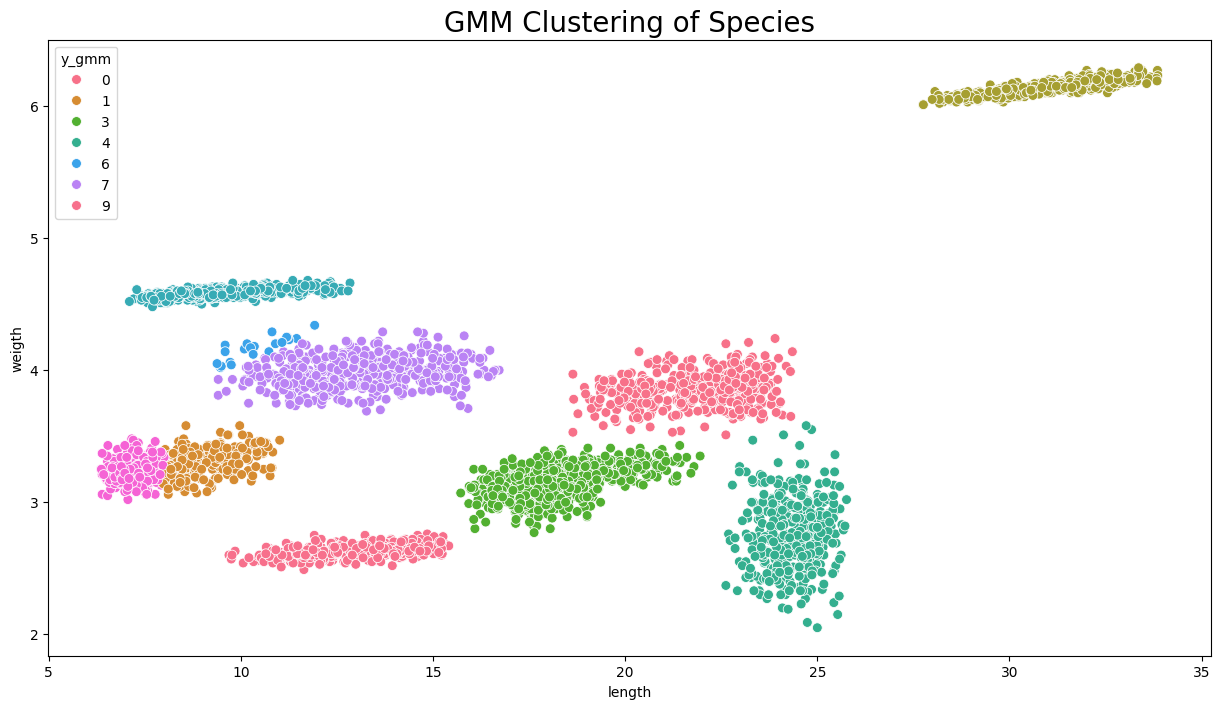

In [88]:
plt.figure(figsize= (15,8))

sns.scatterplot(
    x = 'length',
    y = 'weight',
    hue = 'y_gmm',
    palette = 'husl',
    s=50,
    data=d
)

plt.title('GMM Clustering of Species', fontsize=20)
plt.xlabel('length')
plt.ylabel('weigth')

plt.show()

In [97]:
probs = gmm.predict_proba(X_pca)

confidence = probs.max(axis=1)

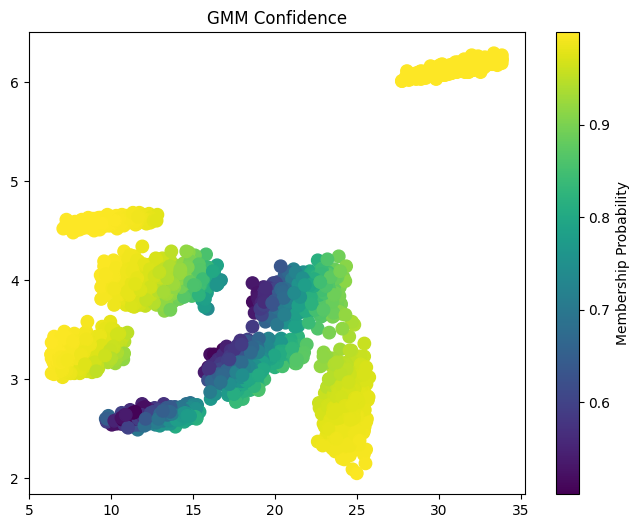

In [100]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['length'],
    X['weight'],
    c=confidence,
    s=80
)

plt.colorbar(label='Membership Probability')
plt.title("GMM Confidence")
plt.show()

## GMM for Setipinna and Otolithoides

In [68]:
X_scaled.shape

(3971, 3)

In [69]:
Y.shape

(3971, 1)

In [70]:
X_gmm = pd.DataFrame()

In [71]:
X_gmm = df.copy()

In [72]:
X_gmm = X_gmm[(X_gmm['species']=='Setipinna taty') | (X_gmm['species']=='Otolithoides biauritus')]

In [73]:
X_gmm.species.value_counts()

species
Setipinna taty            476
Otolithoides biauritus    456
Name: count, dtype: int64

In [74]:
Y_gmm = pd.DataFrame()
Y_gmm['species'] = X_gmm['species']
X_gmm = X_gmm.drop(columns='species')

In [75]:
Y_gmm

,species
891,Otolithoides biauritus
892,Otolithoides biauritus
893,Otolithoides biauritus
894,Otolithoides biauritus
895,Otolithoides biauritus
...,...
3620,Setipinna taty
3621,Setipinna taty
3622,Setipinna taty
3623,Setipinna taty


<Axes: xlabel='weight', ylabel='length'>

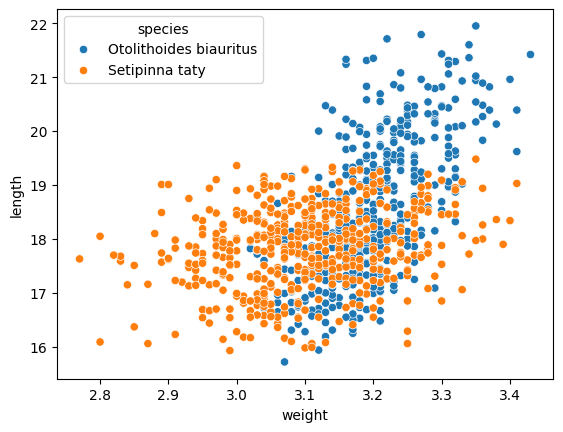

In [76]:
sns.scatterplot(
    x='weight',
    y='length',
    data=X_gmm,
    hue=Y_gmm['species']
)

In [77]:
X_gmm_scaled = scaler.fit_transform(X_gmm)

In [78]:
X_gmm_pca = pca.fit_transform(X_gmm_scaled)

In [79]:
bic_scores = []

for k in range(1,20):
    gmm = GaussianMixture(
        n_components = k,
        random_state = 42
    )
    gmm.fit(X_gmm_pca)
    bic_scores.append(gmm.bic(X_gmm_pca))

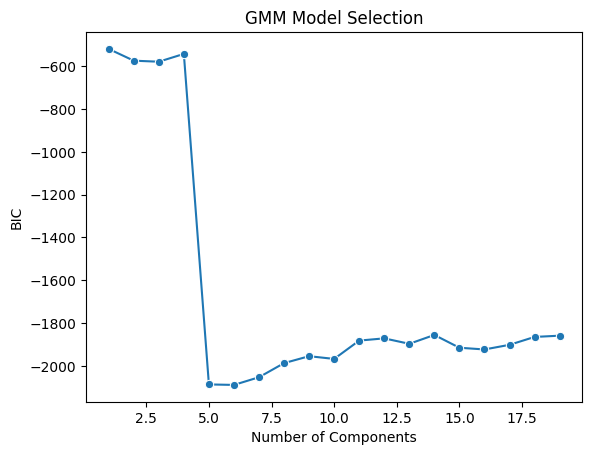

In [80]:
sns.lineplot(
    x=range(1,20),
    y=bic_scores,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("GMM Model Selection")
plt.show()

In [81]:
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

y_gmm_2 = gmm.fit_predict(X_gmm_pca)

In [82]:
np.unique(y_gmm_2)

array([0, 1])

In [83]:
X_gmm['y_gmm_2'] = y_gmm_2.copy()
X_gmm['species'] = Y_gmm.copy()

le = LabelEncoder()

X_gmm['species_encoded'] = le.fit_transform(X_gmm['species'])

In [84]:
X_gmm

,length,weight,w_l_ratio,y_gmm_2,species,species_encoded
891,20.07,3.18,0.16,0,Otolithoides biauritus,0
892,17.21,3.23,0.19,1,Otolithoides biauritus,0
893,16.82,3.08,0.18,1,Otolithoides biauritus,0
894,17.72,3.18,0.18,1,Otolithoides biauritus,0
895,21.43,3.30,0.15,0,Otolithoides biauritus,0
...,...,...,...,...,...,...
3620,17.98,3.17,0.18,1,Setipinna taty,1
3621,17.23,3.20,0.19,1,Setipinna taty,1
3622,19.01,3.04,0.16,0,Setipinna taty,1
3623,17.97,3.35,0.19,1,Setipinna taty,1


<Axes: xlabel='weight', ylabel='length'>

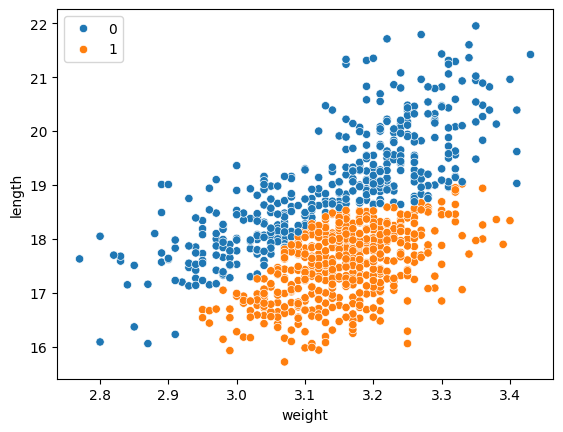

In [85]:
sns.scatterplot(
    x='weight',
    y='length',
    data=X_gmm,
    hue=y_gmm_2
)

In [86]:
acc = accuracy_score(
    X_gmm['species_encoded'],X_gmm['y_gmm_2']
)

In [87]:
acc

0.5085836909871244